In [1]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

df.head()

Saving delhi_ncr_aqi_dataset.csv to delhi_ncr_aqi_dataset.csv


,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe


2020 Rows: 33672
Pre-lockdown rows: 7360
Lockdown rows: 6256

--- Pre-lockdown Averages ---
aqi     391.985326
pm25    218.135340
no2      82.627405
pm10    414.557160
dtype: float64

--- Lockdown Averages ---
aqi     196.245524
pm25     89.346084
no2      34.313012
pm10    169.906602
dtype: float64

--- Percentage Reduction During Lockdown ---
aqi     49.935492
pm25    59.040986
no2     58.472602
pm10    59.014916
dtype: float64


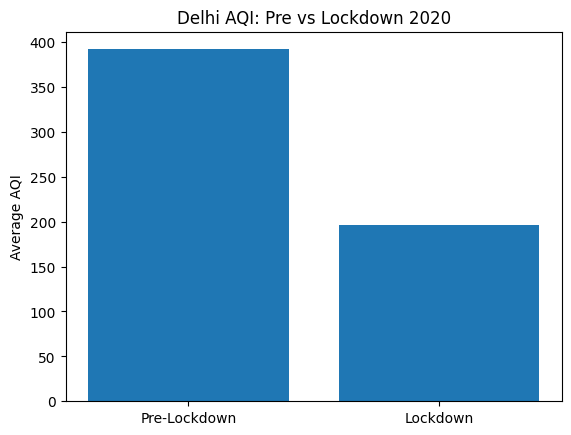

In [2]:

df_2020 = df[df['year'] == 2020].copy()

print("2020 Rows:", df_2020.shape[0])

pre_lockdown = df_2020[
    ((df_2020['month'] == 1) |
     (df_2020['month'] == 2) |
     ((df_2020['month'] == 3) & (df_2020['day'] <= 20)))
]

lockdown = df_2020[
    (((df_2020['month'] == 3) & (df_2020['day'] >= 25)) |
     (df_2020['month'] == 4) |
     (df_2020['month'] == 5))
]

print("Pre-lockdown rows:", pre_lockdown.shape[0])
print("Lockdown rows:", lockdown.shape[0])


pre_avg = pre_lockdown[['aqi', 'pm25', 'no2', 'pm10']].mean()
lockdown_avg = lockdown[['aqi', 'pm25', 'no2', 'pm10']].mean()

print("\n--- Pre-lockdown Averages ---")
print(pre_avg)

print("\n--- Lockdown Averages ---")
print(lockdown_avg)

reduction = ((pre_avg - lockdown_avg) / pre_avg) * 100

print("\n--- Percentage Reduction During Lockdown ---")
print(reduction)


import matplotlib.pyplot as plt

plt.figure()
plt.bar(['Pre-Lockdown', 'Lockdown'],
        [pre_avg['aqi'], lockdown_avg['aqi']])
plt.ylabel("Average AQI")
plt.title("Delhi AQI: Pre vs Lockdown 2020")
plt.show()

During the 2020 COVID lockdown, when traffic virtually stopped and construction halted, Delhi's AQI improved by 50% - from severe (392) to poor (196). This proves that traffic and construction interventions CAN work. "Look at this. During the 2020 lockdown, Delhi's air quality improved by 50% - from hazardous to poor. This wasn't magic. Traffic stopped. Construction halted. And the air cleared.
The problem? We can't lock down the city forever. But what if we could simulate different intervention levels? What if we could predict: 'If we reduce traffic by 30%, how much will air quality improve?'
That's what our tool does

---- Year-wise Averages ----
                   aqi                    pm25                    no2  \
is_weekend           0           1           0           1          0   
year                                                                    
2020        275.986766  260.126045  192.749008  178.979755  75.242649   
2021        272.158712  260.936246  190.476199  172.940343  74.470173   
2022        270.527048  260.857557  191.108390  176.324482  74.737793   
2023        268.084615  253.289648  185.087843  172.338364  72.500548   
2024        267.785803  248.800063  185.402510  165.523150  72.553584   
2025        265.570215  248.017768  182.058671  168.417026  71.245190   

                             pm10              
is_weekend          1           0           1  
year                                           
2020        62.863503  366.538363  339.970861  
2021        60.528418  361.860849  328.776808  
2022        61.884493  363.236936  334.696232  
2023        60.670507  35

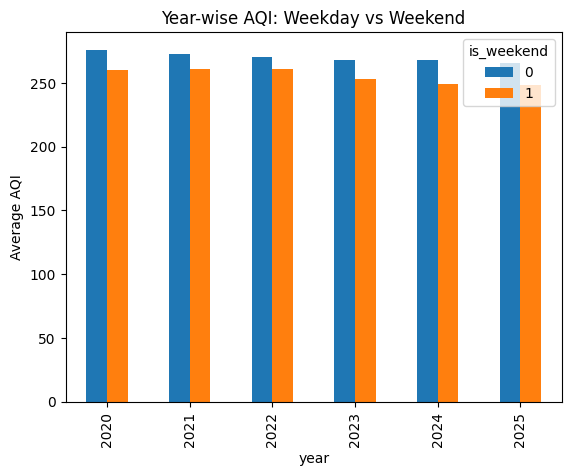

In [3]:
# ==============================
# YEAR-WISE WEEKEND vs WEEKDAY ANALYSIS
# ==============================

# Group by year and weekend indicator
yearly_weekend = df.groupby(['year', 'is_weekend'])[['aqi', 'pm25', 'no2', 'pm10']].mean().unstack()

print("---- Year-wise Averages ----")
print(yearly_weekend)

# Calculate percentage improvement per year (AQI only)
yearly_reduction = ((yearly_weekend['aqi'][0] - yearly_weekend['aqi'][1]) / yearly_weekend['aqi'][0]) * 100

print("\n---- Weekend AQI Improvement (%) by Year ----")
print(yearly_reduction)

# Plot AQI comparison year-wise
import matplotlib.pyplot as plt

aqi_yearly = df.groupby(['year', 'is_weekend'])['aqi'].mean().unstack()

aqi_yearly.plot(kind='bar')
plt.ylabel("Average AQI")
plt.title("Year-wise AQI: Weekday vs Weekend")
plt.show()

Across six consecutive years, weekends consistently show 4–7% lower AQI compared to weekdays. This confirms that even moderate traffic reductions produce measurable air quality improvements.

Available Years:
[np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Available Seasons:
['winter' 'summer' 'monsoon' 'post_monsoon']

---- Year-wise Seasonal Averages ----
              aqi                                            pm25  \
season    monsoon post_monsoon      summer      winter    monsoon   
year                                                                
2020    86.615645   420.683731  214.280009  463.136992  45.397826   
2021    84.926586   421.653226  210.701441  461.283062  44.628038   
2022    84.113863   428.721599  207.000709  459.422917  44.207894   
2023    82.141661   412.313114  202.880080  456.912138  43.186458   
2024    80.441376   417.903576  199.228733  454.026321  42.508179   
2025    79.112349   429.609046  194.630317  451.934149  41.792445   

                                                 pm10               \
season post_monsoon     summer      winter    monsoon post_monsoon   
year                

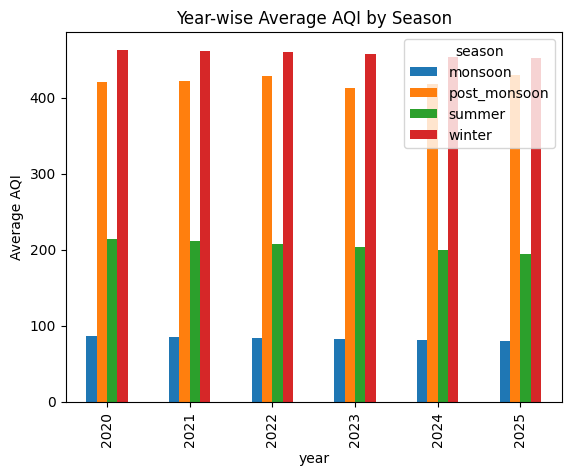


---- Winter vs Summer Difference (%) by Year ----
year
2020    53.732910
2021    54.322745
2022    54.943321
2023    55.597573
2024    56.119563
2025    56.933921
dtype: float64


In [4]:
# ==============================
# YEAR-WISE SEASONAL AQI ANALYSIS
# ==============================

import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Check available years and seasons
print("Available Years:")
print(sorted(df['year'].unique()))

print("\nAvailable Seasons:")
print(df['season'].unique())

# Step 2: Group by year and season
yearly_season = df.groupby(['year', 'season'])[['aqi', 'pm25', 'pm10', 'no2']].mean().unstack()

print("\n---- Year-wise Seasonal Averages ----")
print(yearly_season)

# Step 3: Extract only AQI for clean visualization
aqi_yearly_season = df.groupby(['year', 'season'])['aqi'].mean().unstack()

# Step 4: Plot
aqi_yearly_season.plot(kind='bar')
plt.ylabel("Average AQI")
plt.title("Year-wise Average AQI by Season")
plt.show()

# Step 5: Calculate Winter vs Summer % Difference per year
if 'winter' in aqi_yearly_season.columns and 'summer' in aqi_yearly_season.columns:
    seasonal_difference = ((aqi_yearly_season['winter'] - aqi_yearly_season['summer'])
                           / aqi_yearly_season['winter']) * 100

    print("\n---- Winter vs Summer Difference (%) by Year ----")
    print(seasonal_difference)

A 30% traffic reduction in winter will have much larger absolute impact than the same reduction in monsoon.

STEP 1: LOADING DATA
Total records: 201,664
Date range: 2020-01-01 00:00:00 to 2025-12-31 00:00:00

STEP 2: FEATURE ENGINEERING
Season mapping: {'monsoon': np.int64(0), 'post_monsoon': np.int64(1), 'summer': np.int64(2), 'winter': np.int64(3)}
Day of week mapping: {'Friday': np.int64(0), 'Monday': np.int64(1), 'Saturday': np.int64(2), 'Sunday': np.int64(3), 'Thursday': np.int64(4), 'Tuesday': np.int64(5), 'Wednesday': np.int64(6)}

STEP 3: FEATURE SELECTION

Features selected: 9
Target variable: aqi

STEP 4: PREPARING DATA
Original: 201,664 rows
After dropna: 201,664 rows
Feature matrix: (201664, 9)
Target vector: (201664,)

STEP 5: TRAIN-TEST SPLIT
Training: 161,331 samples
Testing: 40,333 samples

STEP 6: TRAINING MODEL
Training...
Training complete

STEP 7: EVALUATION

Training Set:
  R2: 0.9847
  MAE: 15.73
  RMSE: 21.22

Test Set:
  R2: 0.9620
  MAE: 24.77
  RMSE: 33.43

STEP 8: FEATURE IMPORTANCE

Feature Importance:
  season_encoded      : 0.6485
  month               : 0.2671
 

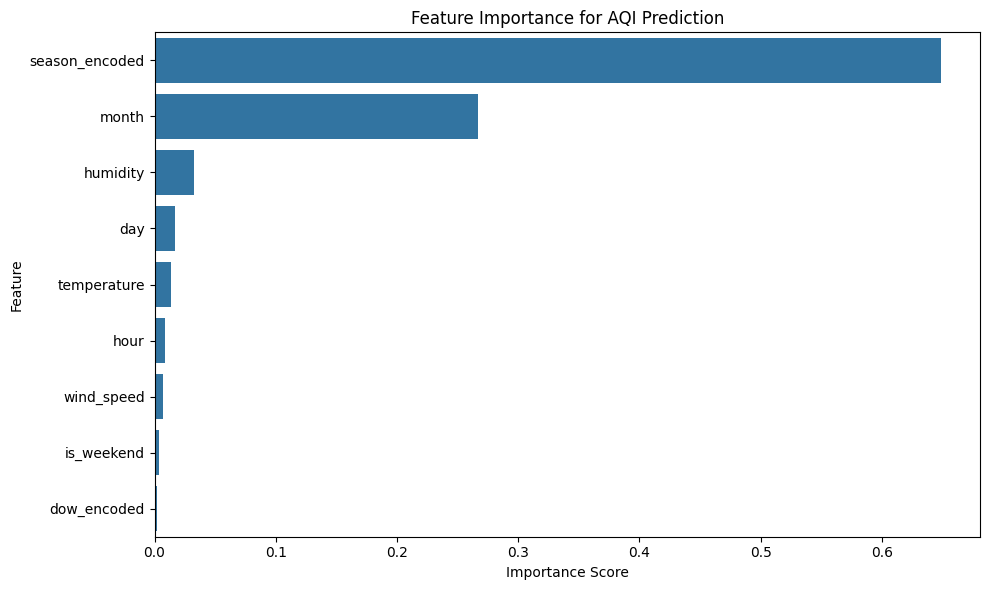

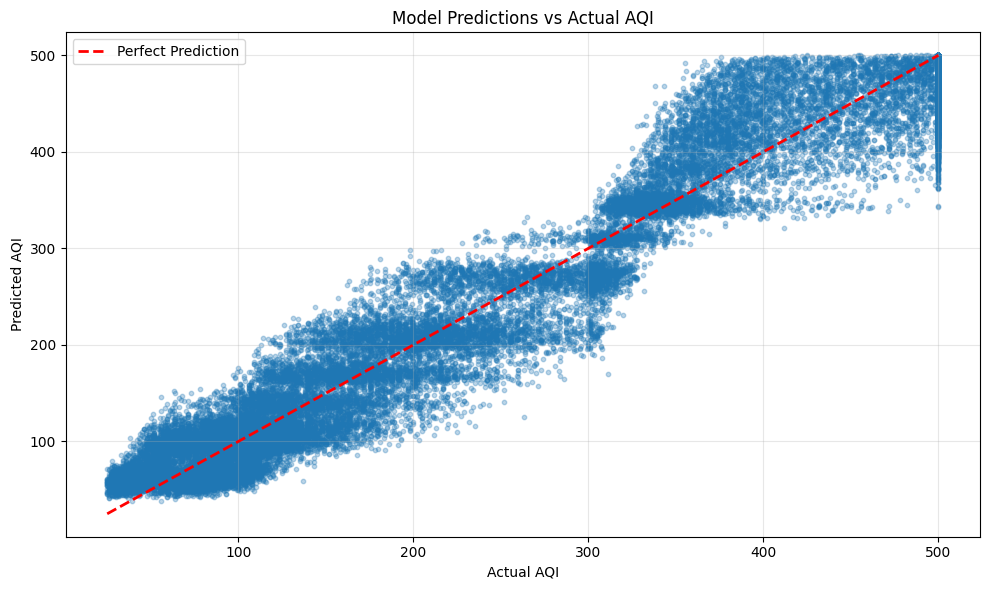

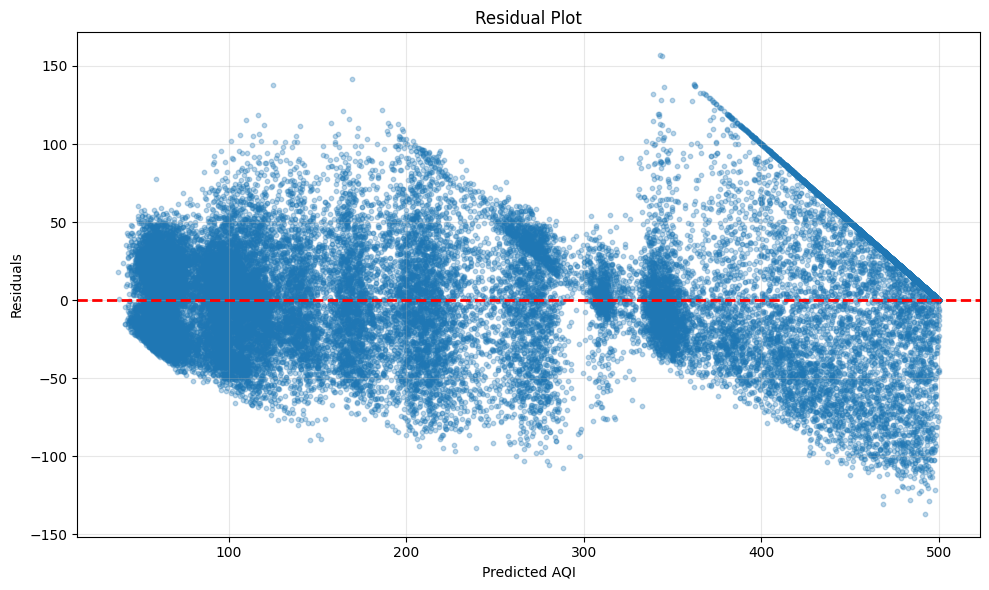

In [5]:
# ============================================================================
# DELHI AIR QUALITY WHAT-IF TOOL - ML MODEL TRAINING
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# STEP 1: LOAD DATA

print("="*70)
print("STEP 1: LOADING DATA")
print("="*70)

df = pd.read_csv('delhi_ncr_aqi_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

print(f"Total records: {len(df):,}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

# STEP 2: FEATURE ENGINEERING

print("\n" + "="*70)
print("STEP 2: FEATURE ENGINEERING")
print("="*70)

model_df = df.copy()

# Encode season
le_season = LabelEncoder()
model_df['season_encoded'] = le_season.fit_transform(model_df['season'])
print(f"Season mapping: {dict(zip(le_season.classes_, le_season.transform(le_season.classes_)))}")

# Encode day_of_week
if model_df['day_of_week'].dtype == 'object':
    le_dow = LabelEncoder()
    model_df['dow_encoded'] = le_dow.fit_transform(model_df['day_of_week'])
    print(f"Day of week mapping: {dict(zip(le_dow.classes_, le_dow.transform(le_dow.classes_)))}")
else:
    model_df['dow_encoded'] = model_df['day_of_week']

# STEP 3: SELECT FEATURES

print("\n" + "="*70)
print("STEP 3: FEATURE SELECTION")
print("="*70)

features = [
    'month',
    'day',
    'hour',
    'dow_encoded',
    'is_weekend',
    'season_encoded',
    'temperature',
    'humidity',
    'wind_speed',
]

target = 'aqi'

print(f"\nFeatures selected: {len(features)}")
print(f"Target variable: {target}")

# STEP 4: PREPARE DATA

print("\n" + "="*70)
print("STEP 4: PREPARING DATA")
print("="*70)

model_data = model_df[features + [target]].dropna()

print(f"Original: {len(model_df):,} rows")
print(f"After dropna: {len(model_data):,} rows")

X = model_data[features]
y = model_data[target]

print(f"Feature matrix: {X.shape}")
print(f"Target vector: {y.shape}")

# STEP 5: TRAIN-TEST SPLIT

print("\n" + "="*70)
print("STEP 5: TRAIN-TEST SPLIT")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"Training: {X_train.shape[0]:,} samples")
print(f"Testing: {X_test.shape[0]:,} samples")

# STEP 6: TRAIN MODEL

print("\n" + "="*70)
print("STEP 6: TRAINING MODEL")
print("="*70)

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("Training...")
model.fit(X_train, y_train)
print("Training complete")

# STEP 7: EVALUATE

print("\n" + "="*70)
print("STEP 7: EVALUATION")
print("="*70)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("\nTraining Set:")
print(f"  R2: {train_r2:.4f}")
print(f"  MAE: {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")

print("\nTest Set:")
print(f"  R2: {test_r2:.4f}")
print(f"  MAE: {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")

# STEP 8: FEATURE IMPORTANCE

print("\n" + "="*70)
print("STEP 8: FEATURE IMPORTANCE")
print("="*70)

feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
for idx, row in feature_importance.iterrows():
    print(f"  {row['feature']:20s}: {row['importance']:.4f}")

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance for AQI Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("\nSaved: feature_importance.png")

# STEP 9: VALIDATION

print("\n" + "="*70)
print("STEP 9: VALIDATION")
print("="*70)

# Weekend effect
test_indices = X_test.index
winter_2024_test = model_df.loc[test_indices]
winter_2024_test = winter_2024_test[
    (winter_2024_test['year'] == 2024) &
    (winter_2024_test['season'] == 'winter')
]

if len(winter_2024_test) > 100:
    weekday_samples = winter_2024_test[winter_2024_test['is_weekend'] == 0]
    weekend_samples = winter_2024_test[winter_2024_test['is_weekend'] == 1]

    if len(weekday_samples) > 0 and len(weekend_samples) > 0:
        weekday_pred = model.predict(weekday_samples[features])
        weekend_pred = model.predict(weekend_samples[features])

        pred_improvement = ((weekday_pred.mean() - weekend_pred.mean()) / weekday_pred.mean()) * 100

        print(f"\nWeekend Effect:")
        print(f"  Weekday AQI: {weekday_pred.mean():.1f}")
        print(f"  Weekend AQI: {weekend_pred.mean():.1f}")
        print(f"  Improvement: {pred_improvement:.1f}%")

# Seasonal effect
winter_test = model_df.loc[test_indices][model_df.loc[test_indices]['season'] == 'winter']
summer_test = model_df.loc[test_indices][model_df.loc[test_indices]['season'] == 'summer']

if len(winter_test) > 0 and len(summer_test) > 0:
    winter_pred = model.predict(winter_test[features])
    summer_pred = model.predict(summer_test[features])

    pred_diff = ((winter_pred.mean() - summer_pred.mean()) / summer_pred.mean()) * 100

    print(f"\nSeasonal Effect:")
    print(f"  Winter AQI: {winter_pred.mean():.1f}")
    print(f"  Summer AQI: {summer_pred.mean():.1f}")
    print(f"  Difference: {pred_diff:.1f}%")

# STEP 10: SAVE MODEL

print("\n" + "="*70)
print("STEP 10: SAVING")
print("="*70)

with open('aqi_prediction_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("Saved: aqi_prediction_model.pkl")

with open('season_encoder.pkl', 'wb') as f:
    pickle.dump(le_season, f)
print("Saved: season_encoder.pkl")

if model_df['day_of_week'].dtype == 'object':
    with open('dow_encoder.pkl', 'wb') as f:
        pickle.dump(le_dow, f)
    print("Saved: dow_encoder.pkl")

with open('model_features.pkl', 'wb') as f:
    pickle.dump(features, f)
print("Saved: model_features.pkl")

metadata = {
    'features': features,
    'target': target,
    'train_size': len(X_train),
    'test_size': len(X_test),
    'train_r2': train_r2,
    'test_r2': test_r2,
    'train_mae': train_mae,
    'test_mae': test_mae,
    'feature_importance': feature_importance.to_dict(),
    'date_trained': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print("Saved: model_metadata.pkl")

# STEP 11: VISUALIZATIONS

print("\n" + "="*70)
print("STEP 11: VISUALIZATIONS")
print("="*70)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Model Predictions vs Actual AQI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('prediction_scatter.png', dpi=300, bbox_inches='tight')
print("Saved: prediction_scatter.png")

residuals = y_test - y_pred_test
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test, residuals, alpha=0.3, s=10)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted AQI')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=300, bbox_inches='tight')
print("Saved: residuals_plot.png")

print("\n" + "="*70)
print("COMPLETE")
print("="*70)

In [6]:
from sklearn.preprocessing import LabelEncoder

le_season = LabelEncoder()
df["season_encoded"] = le_season.fit_transform(df["season"])

le_dow = LabelEncoder()
df["dow_encoded"] = le_dow.fit_transform(df["day_of_week"])

In [7]:
print(le_season.classes_)
print(le_dow.classes_)

['monsoon' 'post_monsoon' 'summer' 'winter']
['Friday' 'Monday' 'Saturday' 'Sunday' 'Thursday' 'Tuesday' 'Wednesday']


In [8]:
features = [
    "month",
    "day",
    "hour",
    "dow_encoded",
    "is_weekend",
    "season_encoded",
    "temperature",
    "humidity",
    "wind_speed",
]